# 02 — Pipeline: PCA + Flow Matching

**Pipeline:** Gene Expression → PCA (reduce to 20d) → Flow Matching → PCA inverse → Gene Expression

This pipeline uses PCA as a linear dimensionality reduction step before applying flow matching.
PCA captures the top principal components of variance, providing a compact representation.
Flow matching then learns to generate new samples in this PCA space, which are mapped back to
gene space via `pca.inverse_transform()`.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import config as cfg
from src.preprocess import set_seed, load_processed
from src.models_flow import train_flow_matching
from src.metrics import distribution_metrics, plot_umap_overlay, plot_training_curves

set_seed()
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 1. Load Preprocessed Data

In [2]:
data = load_processed()
X_all = data["X_all"]
X_train_s = data["X_train_s"]
X_val_s = data["X_val_s"]
X_test_s = data["X_test_s"]
X_all_s = data["X_all_s"]
scaler = data["scaler"]
hvg_names = data["hvg_names"]

print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

Train: (2110, 2000), Val: (263, 2000), Test: (265, 2000)


## 2. PCA Dimensionality Reduction

PCA finds orthogonal directions of maximum variance in the data.
We reduce from 2000 dimensions to 20, fit on training data only.

In [3]:
pca = PCA(n_components=cfg.LATENT_DIM, svd_solver="full", random_state=cfg.SEED)
Z_train_pca = pca.fit_transform(X_train_s).astype(np.float32)
Z_val_pca = pca.transform(X_val_s).astype(np.float32)
Z_test_pca = pca.transform(X_test_s).astype(np.float32)

# Reconstruction quality
X_recon = pca.inverse_transform(Z_test_pca)
pca_recon_mse = float(np.mean((X_test_s - X_recon) ** 2))

print(f"PCA latent shape: {Z_train_pca.shape}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA reconstruction MSE (test, standardized): {pca_recon_mse:.4f}")

PCA latent shape: (2110, 20)
Cumulative variance explained: 0.0998
PCA reconstruction MSE (test, standardized): 1.0436


## 3. Train Flow Matching in PCA Space

Training flow matching in 20-dim PCA space...
  Epoch [   1/500] loss=10.7007
  Epoch [  50/500] loss=4.2293
  Epoch [ 100/500] loss=4.4802
  Epoch [ 150/500] loss=4.2803
  Epoch [ 200/500] loss=3.5812
  Epoch [ 250/500] loss=3.3928
  Epoch [ 300/500] loss=3.3394
  Epoch [ 350/500] loss=3.2720
  Epoch [ 400/500] loss=3.0261
  Epoch [ 450/500] loss=3.5124
  Epoch [ 500/500] loss=3.1730


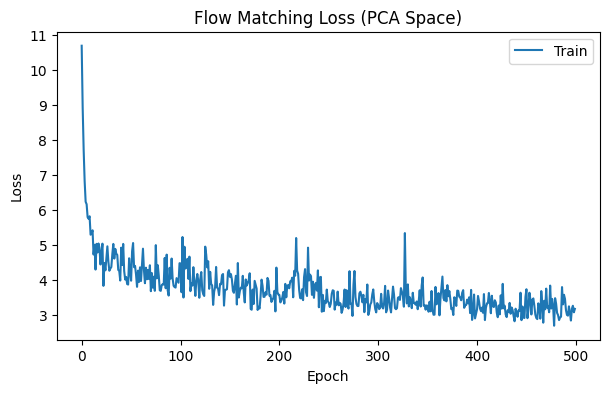

In [4]:
dim_pca = Z_train_pca.shape[1]
print(f"Training flow matching in {dim_pca}-dim PCA space...")

set_seed()
flow_pca, loss_pca = train_flow_matching(
    Z_train=Z_train_pca,
    dim=dim_pca,
    device=cfg.DEVICE,
    hidden=cfg.FM_LATENT_HIDDEN,
    n_layers=cfg.FM_LATENT_LAYERS,
    lr=cfg.FM_LATENT_LR,
    batch_size=cfg.FM_LATENT_BATCH_SIZE,
    n_epochs=cfg.FM_LATENT_EPOCHS,
    print_every=50,
)

plot_training_curves(loss_pca, title="Flow Matching Loss (PCA Space)")
plt.show()

## 4. Generate Synthetic Cells

Sample from noise → integrate through learned flow → PCA inverse transform → inverse StandardScaler

In [5]:
n_gen = len(X_all)
print(f"Generating {n_gen} synthetic cells...")

set_seed()
Z_gen_pca = flow_pca.sample(n_gen, dim_pca, cfg.DEVICE, n_steps=cfg.FM_SAMPLE_STEPS)

# Map back: PCA inverse → unstandardize
X_gen_pca_s = pca.inverse_transform(Z_gen_pca).astype(np.float32)
X_gen_pca = scaler.inverse_transform(X_gen_pca_s).astype(np.float32)

print(f"Generated shape: {X_gen_pca.shape}")
print(f"Value range: [{X_gen_pca.min():.2f}, {X_gen_pca.max():.2f}]")

Generating 2638 synthetic cells...
Generated shape: (2638, 2000)
Value range: [-1.66, 6.81]


## 5. Quick Evaluation

Gene Mean MSE: 0.000073
Gene Std MSE:  0.130156


/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


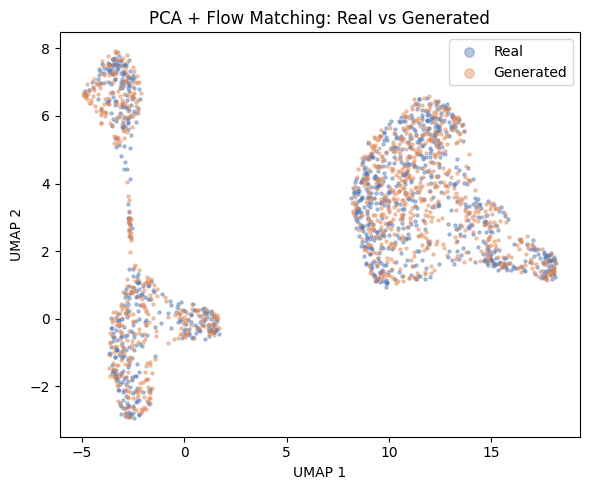

In [6]:
metrics = distribution_metrics(X_all, X_gen_pca)
print(f"Gene Mean MSE: {metrics['Mean MSE']:.6f}")
print(f"Gene Std MSE:  {metrics['Std MSE']:.6f}")

plot_umap_overlay(X_all, X_gen_pca, title="PCA + Flow Matching: Real vs Generated")
plt.tight_layout()
plt.show()

## 6. Save Results

In [7]:
import torch, joblib

os.makedirs(cfg.MODEL_DIR, exist_ok=True)
torch.save(flow_pca.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_pca.pt"))
joblib.dump(pca, os.path.join(cfg.MODEL_DIR, "pca.joblib"))
np.save(os.path.join(cfg.DATA_DIR, "X_gen_pca.npy"), X_gen_pca)

print("Saved: flow_pca.pt, pca.joblib, X_gen_pca.npy")

Saved: flow_pca.pt, pca.joblib, X_gen_pca.npy
